# EDA on MPG dataset

### Topics covered:
- Data cleaning
- Univariate Analysis

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

data_file = "data_MPG.csv"

In [50]:
df = pd.read_csv(data_file)
# print(df.sample(5))
print(df.head(5))
# print(df.tail(5))

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


Great — you’re looking at a subset of the **MPG dataset** (Auto MPG dataset from the UCI Machine Learning Repository). This dataset is widely used in data science and machine learning for regression and exploratory data analysis (EDA).

---

### Columns in the dataset:

1. **mpg**

   * Miles per gallon → the fuel efficiency of the car.
   * Higher values = better fuel economy.
   * This is usually treated as the **target variable** in regression tasks.

2. **cylinders**

   * Number of engine cylinders.
   * Common values: 3, 4, 5, 6, 8.
   * Higher cylinders generally mean more power but worse fuel economy.

3. **displacement**

   * Engine displacement in cubic inches (ci).
   * Larger displacement = larger engine size.
   * Typically correlates with horsepower and weight.

4. **horsepower**

   * Horsepower of the car (engine power).
   * Higher horsepower = faster acceleration, lower mpg usually.

5. **weight**

   * Vehicle weight (in pounds).
   * Heavier cars generally consume more fuel (lower mpg).

6. **acceleration**

   * Time taken to go from 0 to 60 mph (in seconds).
   * Lower values = faster acceleration.
   * Influenced by horsepower and weight.

7. **model\_year**

   * Last two digits of the car’s model year (70 = 1970, 81 = 1981).
   * Useful for observing trends over time (fuel efficiency improved in later years).

8. **origin**

   * Region where the car was manufactured:

     * 1 or `"usa"` → American cars
     * 2 or `"europe"` → European cars
     * 3 or `"japan"` → Japanese cars
   * Often used to compare car design philosophies across regions.

9. **name**

   * The full car name (make + model).
   * Example: `"ford thunderbird"`, `"mazda 626"`.

---


In [52]:
#I want to know about the column datatypes, etc
# print(df.info()) # gives approx memory usage...not very accurate
print(df.info(memory_usage="deep")) # gives accurate memory usage

# observ: horsepower is missing 6 values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 74.0 KB
None


In [43]:
# stats on each columns
print(df.describe())

#observ: 

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.568090   76.010050  
std        2.757689    3.697627  
min        8.000000   70.000000  
25%       13.825000   73.000000  
50%       15.500000   76.000000  
75%       17.175000   79.000000  
max       24.800000   82.000000  


### 1. **Data Cleaning & Preparation**
* Handle data types
* Check missing values (e.g., horsepower sometimes has `"?"`).
* Remove/handle outliers in mpg, weight, horsepower, etc.

In [44]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [45]:
# percentage of data missing:
(6/398) * 100 

1.507537688442211

In [46]:
# I want to see which values are missing
print(df[df["horsepower"].isnull()])

# observ: Less than 2% are missing...so we can drop these...but I would not.

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
32   25.0          4          98.0         NaN    2046          19.0   
126  21.0          6         200.0         NaN    2875          17.0   
330  40.9          4          85.0         NaN    1835          17.3   
336  23.6          4         140.0         NaN    2905          14.3   
354  34.5          4         100.0         NaN    2320          15.8   
374  23.0          4         151.0         NaN    3035          20.5   

     model_year  origin                  name  
32           71     usa            ford pinto  
126          74     usa         ford maverick  
330          80  europe  renault lecar deluxe  
336          80     usa    ford mustang cobra  
354          81  europe           renault 18i  
374          82     usa        amc concord dl  


In [47]:
# STEP1: Short tutorial on null values
df = pd.read_csv(data_file)
print(df.isnull().sum())

# STEP2:
# options to handle null values:

# Removal:
# df = df.dropna() # option rows with null values
# df = df.dropna(axis=1) # drop columns with NaN


# Imputation:
# df['horsepower'] = df['horsepower'].fillna(7) # fill with constant
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean()) # mean
# df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median()) # → median
# df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mode()[0]) # → mode


# Forward/Backward fill: Not shown here
# Advanced: use sklearn.impute (KNN, IterativeImputer) not shown here
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [48]:
# Handle data types (`horsepower` might need conversion to uint8 because values are in the range 0-255).

print("Before optimization:")
print(df.info(memory_usage="deep"))

# df['horsepower'] = df['horsepower'].astype("uint8")
df['horsepower'] = pd.to_numeric(df['horsepower'], downcast='integer') # better

# df['model_year'] = df['model_year'].astype("uint8")
df['model_year'] = pd.to_numeric(df['model_year'], downcast='integer') # better

df['cylinders']  = df['cylinders'].astype("category")
df['origin']     = df['origin'].astype("category")

print("\nAfter optimization:")
print(df.info(memory_usage="deep"))

# observ: Memory usage went down drastically

Before optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 74.0 KB
None

After optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float64 
 1   cylinders     398 non-null    category
 2   displacement  398 non-null   

In [53]:
# Handle outliers in mpg, weight, horsepower, etc.

#STEP1: Find outliers
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    print(f"\nColumn: {col}")
    print(outliers)



Column: mpg
322    46.6
Name: mpg, dtype: float64

Column: cylinders
Series([], Name: cylinders, dtype: int64)

Column: displacement
Series([], Name: displacement, dtype: float64)

Column: horsepower
6      220.0
7      215.0
8      225.0
13     225.0
25     215.0
27     210.0
67     208.0
94     215.0
95     225.0
116    230.0
Name: horsepower, dtype: float64

Column: weight
Series([], Name: weight, dtype: int64)

Column: acceleration
7       8.5
9       8.5
11      8.0
59     23.5
299    24.8
326    23.7
394    24.6
Name: acceleration, dtype: float64

Column: model_year
Series([], Name: model_year, dtype: int64)


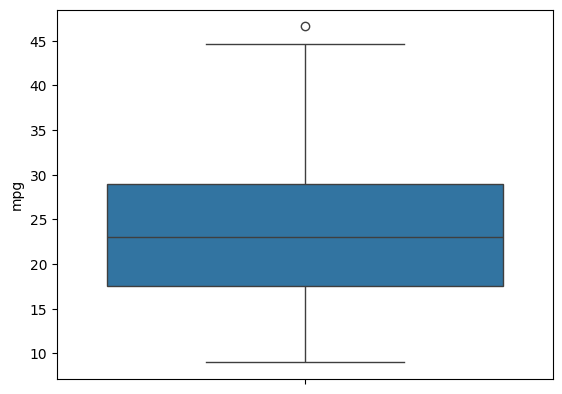

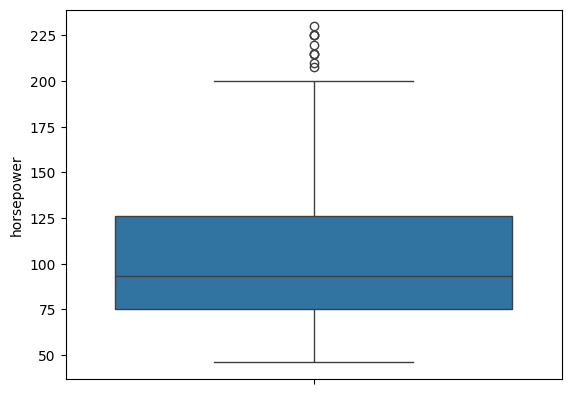

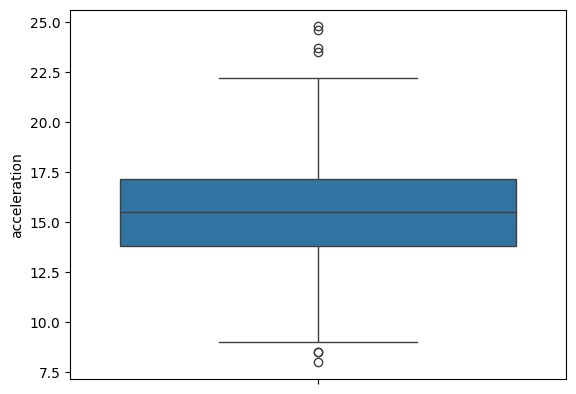

In [56]:
# STEP2: Lets visually see them:
columns = ["mpg", "horsepower", "acceleration"]
for col in  columns:    
    sns.boxplot(data=df, y=col)
    plt.show()
    print("\n")


In [59]:
# STEP3: I am choosing to cap them....there are many other options too, but I am keeping it simple
columns = ["mpg", "horsepower", "acceleration"]
for col in columns:
    lower_cap = df[col].quantile(0.05)
    upper_cap = df[col].quantile(0.95)
    df[col] = df[col].clip(lower=lower_cap, upper=upper_cap)


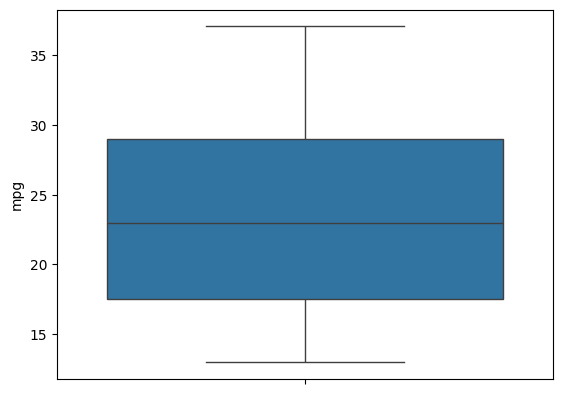

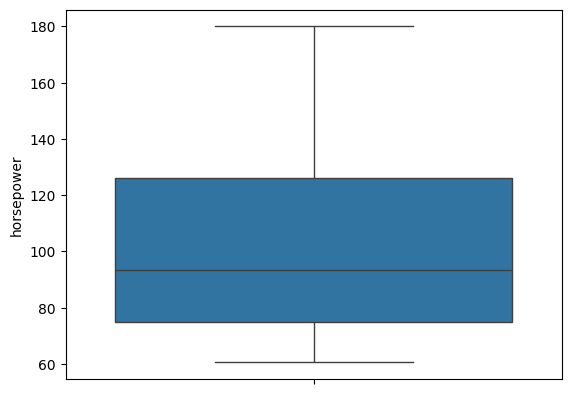

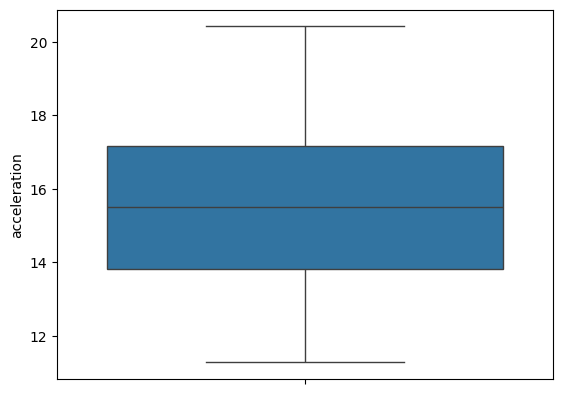

In [61]:
# STEP4: check for outliers again. There should be none

columns = ["mpg", "horsepower", "acceleration"]
for col in  columns:    
    sns.boxplot(data=df, y=col)
    plt.show()
    print("\n")

# observ: Outliers have been capped

### 2. **Univariate Analysis**

* Distribution plots:

  * Histogram/Kernel Density Plot of `mpg` (is it normal, skewed?).
  * Histograms for `horsepower`, `weight`, `acceleration`.
* Count plots:

  * Distribution of `cylinders`, `model_year`, `origin`.

---


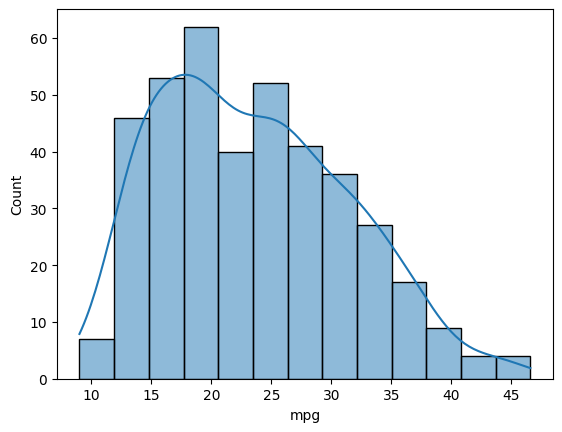

In [26]:
# hist of mpg
sns.histplot(x="mpg", data=df, kde=True)
plt.show()

#observ:

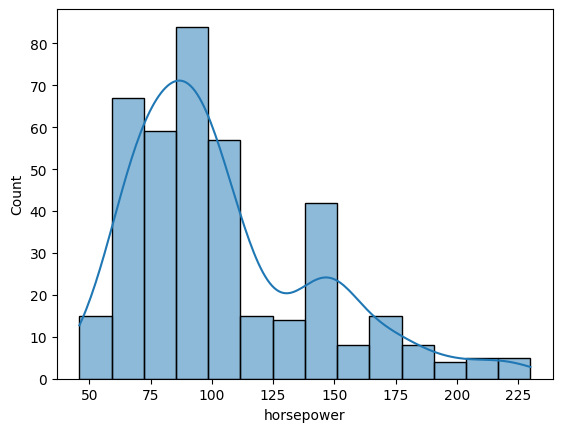

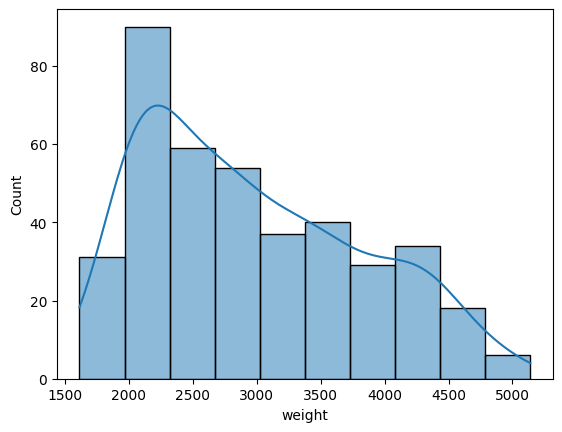

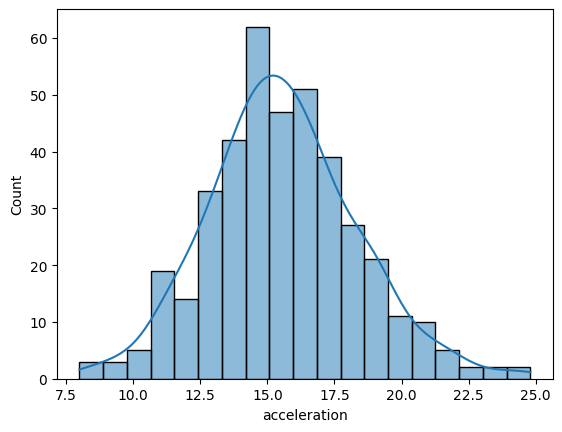

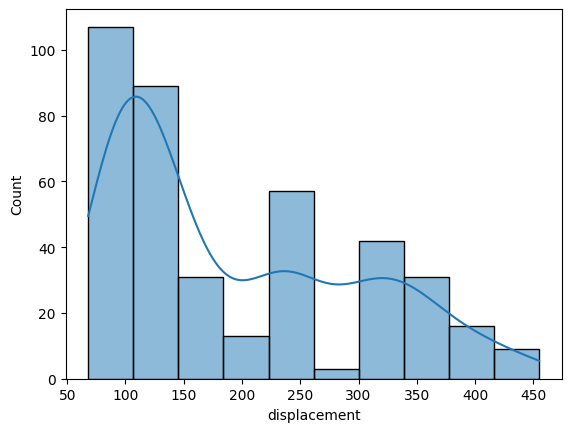

In [27]:
# hist of horsepower, weight, acceleration, displacement
columns = ["horsepower", "weight", "acceleration", "displacement"]
for col in columns:
    sns.histplot(x=col, data=df, kde=True)
    plt.show()
    print("\n")

# observ:

In [28]:
# Now I want to know how much my data is varing away form normal distribution: skewness, kurtosis, etc
# Select numeric columns
numeric_cols = ["mpg", "horsepower", "weight", "acceleration", "displacement"]

# Skewness
skewness = df[numeric_cols].skew()
print("Skewness:\n", skewness)

# Kurtosis
kurtosis = df[numeric_cols].kurtosis()
print("\nKurtosis:\n", kurtosis)

# Skewness:
# ~0 → symmetric
# >0 → right-skewed
# <0 → left-skewed

# Kurtosis:
# ~0 → normal-like
# 0 → heavy tails (leptokurtic)
# <0 → light tails (platykurtic)

Skewness:
 mpg             0.457066
horsepower      1.095552
weight          0.531063
acceleration    0.278777
displacement    0.719645
dtype: float64

Kurtosis:
 mpg            -0.510781
horsepower      0.753509
weight         -0.785529
acceleration    0.419497
displacement   -0.746597
dtype: float64


In [29]:
# OPTIONAL (NEED TO KNOW WHAT THESE MEANS): Now perform stats
from scipy.stats import shapiro, normaltest, anderson

for col in numeric_cols:
    print(f"\nColumn: {col}")
    
    # Shapiro-Wilk test
    stat, p = shapiro(df[col])
    print(f"Shapiro-Wilk: stat={stat:.3f}, p={p:.3f}")
    
    # D'Agostino's K-squared test
    stat, p = normaltest(df[col])
    print(f"D'Agostino's K-squared: stat={stat:.3f}, p={p:.3f}")
    
    # Anderson-Darling test
    result = anderson(df[col])
    print(f"Anderson-Darling: stat={result.statistic:.3f}")



Column: mpg
Shapiro-Wilk: stat=0.968, p=0.000
D'Agostino's K-squared: stat=20.555, p=0.000
Anderson-Darling: stat=3.443

Column: horsepower
Shapiro-Wilk: stat=0.905, p=0.000
D'Agostino's K-squared: stat=62.436, p=0.000
Anderson-Darling: stat=12.581

Column: weight
Shapiro-Wilk: stat=0.941, p=0.000
D'Agostino's K-squared: stat=46.086, p=0.000
Anderson-Darling: stat=7.302

Column: acceleration
Shapiro-Wilk: stat=0.992, p=0.040
D'Agostino's K-squared: stat=7.628, p=0.022
Anderson-Darling: stat=0.809

Column: displacement
Shapiro-Wilk: stat=0.880, p=0.000
D'Agostino's K-squared: stat=53.270, p=0.000
Anderson-Darling: stat=17.899


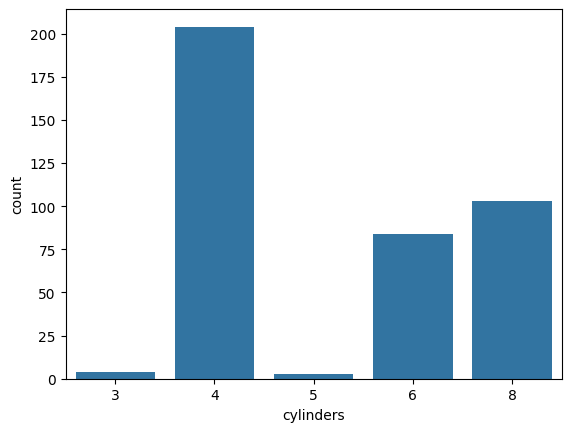

In [30]:
# step1: draw countplot
sns.countplot(x="cylinders", data=df)
plt.show()

# observ:

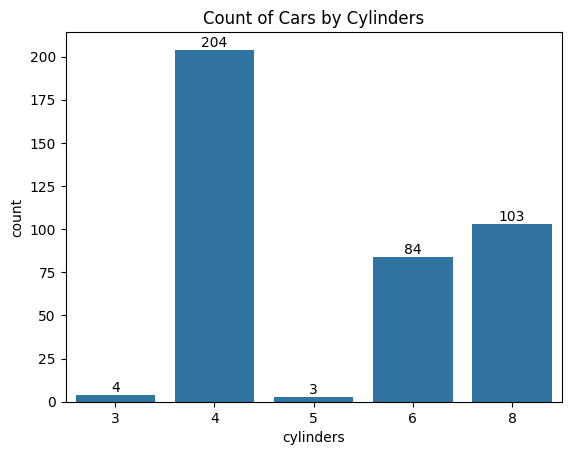

In [31]:
# step2: I want to annotate
ax = sns.countplot(x="cylinders", data=df)

# Add annotations
for container in ax.containers:
    ax.bar_label(container)

plt.title("Count of Cars by Cylinders")
plt.show()

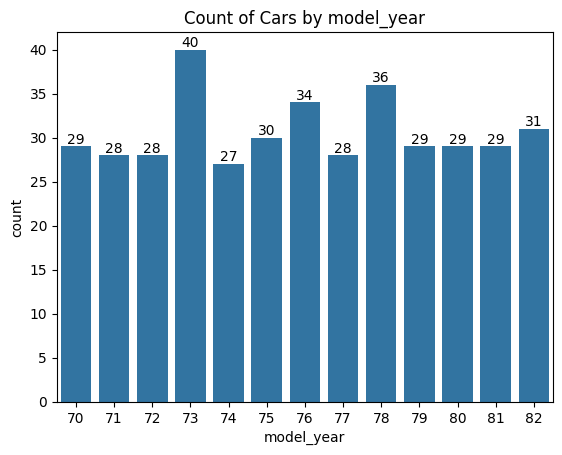

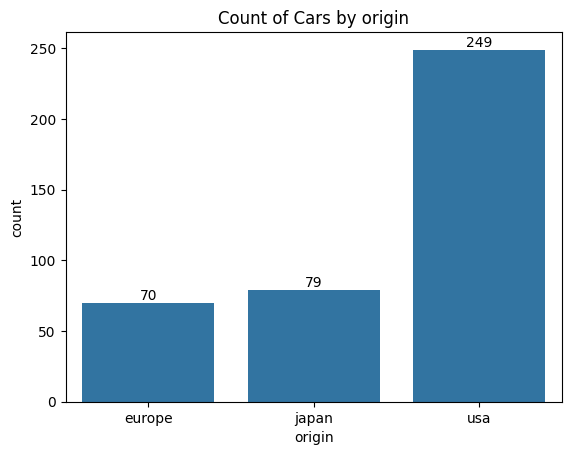

In [32]:
# Now I want countplot of model_year, origin. SO I use for loop.

columns = ["model_year", "origin"]

for col in  columns:
    ax = sns.countplot(x=col, data=df)
    
    # Add annotations
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.title(f"Count of Cars by {col}")
    plt.show()
    print("\n")

# observ: